In [26]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator

# Load your unsorted data
data = np.loadtxt('test1.txt')
x = data[:, 0]
y = data[:, 1]
z = data[:, 2]
w = data[:, 3]

# Combine coordinates into points array
points = np.column_stack((x, y, z))

# Create the interpolator for scattered data
interpolator = LinearNDInterpolator(points, w)

# Define the regular grid bounds (min to max of your data)
offset = 0.1
x_min, x_max = x.min() + offset, x.max() - offset
y_min, y_max = y.min() + offset, y.max() - offset
z_min, z_max = z.min() + offset, z.max() - offset

# Create a 20x20x20 regular grid
grid_size = 15
x_regular = np.linspace(x_min, x_max, grid_size)
y_regular = np.linspace(y_min, y_max, grid_size)
z_regular = np.linspace(z_min, z_max, grid_size)

# Create meshgrid for the regular grid
X, Y, Z = np.meshgrid(x_regular, y_regular, z_regular, indexing='ij')

# Flatten the grid points for interpolation
grid_points = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))

# Interpolate weights onto the regular grid
w_regular_flat = interpolator(grid_points)

# Reshape back to 3D grid
w_regular = w_regular_flat.reshape(grid_size, grid_size, grid_size)

# Optional: Handle NaN values (points outside convex hull)
# You can replace NaN with 0 or nearest neighbor value
w_regular = np.nan_to_num(w_regular, nan=0.0)  # Replace NaN with 0

# Now w_regular is your 20x20x20 regular grid of interpolated weights
print(f"Regular grid shape: {w_regular.shape}")
print(f"Number of interpolated points: {np.sum(~np.isnan(w_regular_flat))}")

# Optional: Save the regular grid to a file
np.savetxt('regular_grid.txt', w_regular.reshape(-1, 1))

Regular grid shape: (15, 15, 15)
Number of interpolated points: 3375


In [27]:
import plotly.graph_objects as go

W = w_regular

# ============================================
# PLOTLY ISOSURFACE
# ============================================

# Choose isosurface value (e.g., 50% of max value)
isovalue = W.max() * 0.001

# Create the isosurface
fig = go.Figure(data=go.Isosurface(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=W.flatten(),
    isomin=isovalue,
    isomax=isovalue,
    colorscale='Viridis',
    caps=dict(x_show=False, y_show=False, z_show=False),
    surface_count=1,
    opacity=0.8,
    showscale=True,
    colorbar=dict(title='Value')
))

# Update layout
fig.update_layout(
    title=f'Isosurface at value = {isovalue:.4f}',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=800,
    height=800
)

fig.show()

[-4.16945603e-01 -3.57381945e-01 -2.97818288e-01 -2.38254630e-01
 -1.78690973e-01 -1.19127315e-01 -5.95636575e-02 -4.44089210e-16
  5.95636575e-02  1.19127315e-01  1.78690973e-01  2.38254630e-01
  2.97818288e-01  3.57381945e-01  4.16945603e-01]


RuntimeError: Error in qhull Delaunay triangulation calculation: singular input data (exitcode=2); use python verbose option (-v) to see original qhull error.

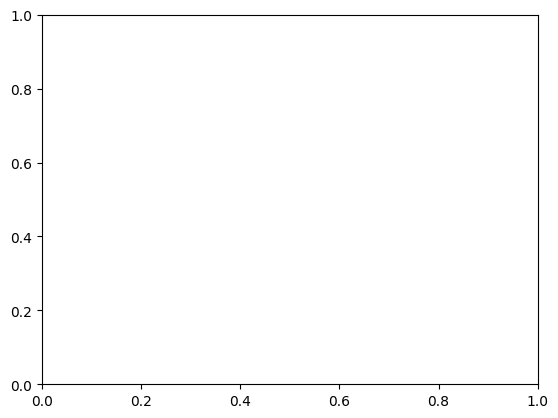

In [28]:
import matplotlib.pyplot as plt
xx = grid_points[:,0]
yy = grid_points[:,1]
zz = grid_points[:,2]
print(np.unique(zz))
ww = w_regular_flat
z_min = np.unique(zz)[9]
plt.tricontourf(xx[yy==z_min],yy[yy==z_min],ww[yy==z_min])

In [ ]:
import plotly.graph_objects as go



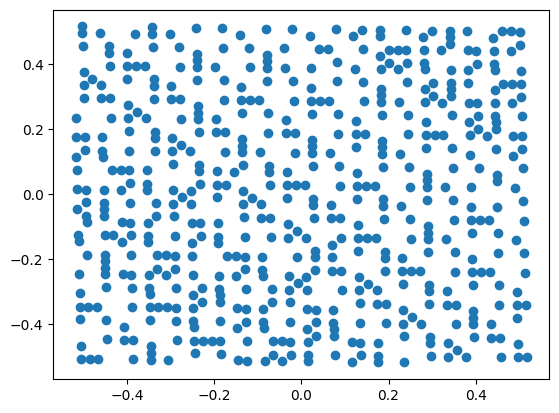

In [ ]:

plt.scatter(x[y<-0.45],z[y<-0.45])


In [ ]:
a = [[1,1,1],[2,2,2],[1,1,1]]
b = np.unique(a,axis=0)
print(b)

[[1 1 1]
 [2 2 2]]
